In [1]:
!pip install -q pyspark
from pyspark.sql import SparkSession, Window
import pyspark.sql.functions as F

spark = SparkSession.builder.appName("BGD_RainfallFoodDebt").getOrCreate()
print(spark.version)

26/07/04 13:02:29 WARN Utils: Your hostname, VM resolves to a loopback address: 127.0.1.1; using 10.0.2.15 instead (on interface enp0s3)
26/07/04 13:02:29 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/07/04 13:02:30 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


3.5.8


In [3]:
DIVISIONS = ['BD10','BD20','BD30','BD40','BD45','BD50','BD55','BD60']
YMIN, YMAX = 1999, 2024
DIV_MAP = {'Barisal':'BD10','Chittagong':'BD20','Dhaka':'BD30','Khulna':'BD40',
           'Mymensingh':'BD45','Rajshahi':'BD50','Rangpur':'BD55','Sylhet':'BD60'}

# place the 3 CSVs in the same folder as this notebook, or give full path
rf_raw = spark.read.csv('bgdrainfallsubnatfull.csv', header=True, inferSchema=True)
fp_raw = spark.read.csv('wfp_food_prices_bgd.csv', header=True, inferSchema=True)
dbt_raw = spark.read.csv('externaldebt_bgd.csv', header=True, inferSchema=True)

rf_raw.printSchema()
fp_raw.printSchema()
dbt_raw.printSchema()

root
 |-- date: date (nullable = true)
 |-- adm_level: integer (nullable = true)
 |-- adm_id: integer (nullable = true)
 |-- PCODE: string (nullable = true)
 |-- n_pixels: double (nullable = true)
 |-- rfh: double (nullable = true)
 |-- rfh_avg: double (nullable = true)
 |-- r1h: double (nullable = true)
 |-- r1h_avg: double (nullable = true)
 |-- r3h: double (nullable = true)
 |-- r3h_avg: double (nullable = true)
 |-- rfq: double (nullable = true)
 |-- r1q: double (nullable = true)
 |-- r3q: double (nullable = true)
 |-- version: string (nullable = true)

root
 |-- date: string (nullable = true)
 |-- admin1: string (nullable = true)
 |-- admin2: string (nullable = true)
 |-- market: string (nullable = true)
 |-- market_id: integer (nullable = true)
 |-- latitude: double (nullable = true)
 |-- longitude: double (nullable = true)
 |-- category: string (nullable = true)
 |-- commodity: string (nullable = true)
 |-- commodity_id: integer (nullable = true)
 |-- unit: string (nullable = tr

In [4]:
rf = rf_raw.filter((F.col('adm_level')==1) & (F.col('PCODE').isin(DIVISIONS)))
rf = rf.withColumn('date', F.to_date('date')) \
       .withColumn('year', F.year('date')) \
       .withColumn('month', F.month('date')) \
       .filter((F.col('year')>=YMIN)&(F.col('year')<=YMAX))

rf_m = rf.groupBy('PCODE','year','month').agg(
    F.sum('rfh').alias('rainfall_mm'),
    F.sum('rfh_avg').alias('rainfall_historic_avg_mm')
).withColumn('rainfall_anomaly_pct',
    (F.col('rainfall_mm')-F.col('rainfall_historic_avg_mm'))/F.col('rainfall_historic_avg_mm')*100
).withColumnRenamed('PCODE','pcode')

print("rainfall monthly rows:", rf_m.count())  # expect 2496
rf_m.show(5)

rainfall monthly rows: 2496


+-----+----+-----+-----------------+------------------------+--------------------+
|pcode|year|month|      rainfall_mm|rainfall_historic_avg_mm|rainfall_anomaly_pct|
+-----+----+-----+-----------------+------------------------+--------------------+
| BD10|2015|    9|        818.59788|       671.7559739999999|   21.85941200129917|
| BD20|1999|    8|          591.549|               485.26768|   21.90158635745121|
| BD20|2004|    7|715.7431100000001|               650.96501|     9.9510878472562|
| BD20|2015|    2|       11.2797336|      13.822835999999999| -18.397833845384543|
| BD20|2015|    8|        469.35584|               485.26768| -3.2789820249310617|
+-----+----+-----+-----------------+------------------------+--------------------+
only showing top 5 rows



In [5]:
fp = fp_raw.withColumn('date', F.to_date('date','dd/MM/yyyy')) \
           .withColumn('year', F.year('date')).withColumn('month', F.month('date')) \
           .filter((F.col('year')>=YMIN)&(F.col('year')<=YMAX))

map_expr = F.create_map([F.lit(x) for pair in DIV_MAP.items() for x in pair])
fp = fp.withColumn('pcode', map_expr[F.col('admin1')]).filter(F.col('pcode').isNotNull())

RICE = ['Rice (coarse, BR-8/ 11/, Guti Sharna)','Rice (coarse)','Rice (coarse, Guti Sharna)',
        'Rice (medium grain)','Rice (Kajla)','Rice (Nurjahan)','Rice (Pyzam)',
        'Rice (BRRI-28)','Rice (BRRI-29)','Rice (BRRI-49)','Rice (Gazi)']
FLOUR = ['Wheat flour']
OIL = ['Oil (palm)','Oil (mustard)','Oil (soybean, fortified)']
LENTILS = ['Lentils (masur)']
groups = {'rice':RICE,'flour':FLOUR,'oil':OIL,'lentils':LENTILS}

fp = fp.withColumn('norm_price', F.when(F.col('unit')=='100 KG', F.col('usdprice')/100.0).otherwise(F.col('usdprice')))

frames = {}
for name, items in groups.items():
    frames[name] = fp.filter(F.col('commodity').isin(items)) \
                     .groupBy('pcode','year','month').agg(F.mean('norm_price').alias(f'{name}_price'))

fp_m = frames['rice']
for name in ['flour','oil','lentils']:
    fp_m = fp_m.join(frames[name], on=['pcode','year','month'], how='outer')

fp_m = fp_m.withColumnRenamed('rice_price','rice_price_usd_per_kg') \
           .withColumnRenamed('flour_price','flour_price_usd_per_kg') \
           .withColumnRenamed('oil_price','oil_price_usd_per_l') \
           .withColumnRenamed('lentils_price','lentils_price_usd_per_kg')

# avg_food_price = mean of AVAILABLE (non-null) commodity prices, like pandas .mean(skipna=True)
fp_m = fp_m.withColumn('avg_food_price_usd_per_kg', F.expr("""
    aggregate(filter(array(rice_price_usd_per_kg,flour_price_usd_per_kg,oil_price_usd_per_l,lentils_price_usd_per_kg), x -> x is not null),
              0D, (acc,x)->acc+x)
    / size(filter(array(rice_price_usd_per_kg,flour_price_usd_per_kg,oil_price_usd_per_l,lentils_price_usd_per_kg), x -> x is not null))
"""))

print("food price monthly rows:", fp_m.count())
fp_m.orderBy('pcode','year','month').show(5)

food price monthly rows: 1498


+-----+----+-----+---------------------+----------------------+-------------------+------------------------+-------------------------+
|pcode|year|month|rice_price_usd_per_kg|flour_price_usd_per_kg|oil_price_usd_per_l|lentils_price_usd_per_kg|avg_food_price_usd_per_kg|
+-----+----+-----+---------------------+----------------------+-------------------+------------------------+-------------------------+
| BD10|2006|    8|                 0.25|                  NULL|               NULL|                    NULL|                     0.25|
| BD10|2006|    9|                 NULL|                  NULL|               NULL|                    0.79|                     0.79|
| BD10|2006|   12|                 NULL|                  0.34|               NULL|                    NULL|                     0.34|
| BD10|2007|    1|                 NULL|                  0.37|               NULL|                    NULL|                     0.37|
| BD10|2007|    2|                 NULL|               

In [6]:
IND = {
    'External debt stocks, total (DOD, current US$)': 'debt_stock_total_usd',
    'Debt service on external debt, total (TDS, current US$)': 'debt_service_total_usd',
    'External debt stocks (% of GNI)': 'debt_stock_pct_gni'
}
dbt = dbt_raw.filter(F.col('`Indicator Name`').isin(list(IND.keys())))
dbt_p = dbt.groupBy('Year').pivot('Indicator Name', list(IND.keys())).agg(F.first('Value'))
for orig, new in IND.items():
    dbt_p = dbt_p.withColumnRenamed(orig, new)
dbt_p = dbt_p.withColumnRenamed('Year','year').filter((F.col('year')>=YMIN)&(F.col('year')<=YMAX))

months_df = spark.createDataFrame([(i,) for i in range(1,13)], ['month'])
div_df = spark.createDataFrame([(d,) for d in DIVISIONS], ['pcode'])
dbt_m = dbt_p.crossJoin(months_df).crossJoin(div_df)

print("debt annual rows:", dbt_p.count())      # expect 26
print("debt broadcast rows:", dbt_m.count())   # expect 2496
dbt_p.show(5)

debt annual rows: 26


debt broadcast rows: 2496
+----+--------------------+----------------------+------------------+
|year|debt_stock_total_usd|debt_service_total_usd|debt_stock_pct_gni|
+----+--------------------+----------------------+------------------+
|2003|    1.84403775754E10|         6.591521392E8|  29.4649511156153|
|2007|    2.15235441774E10|        1.0082456043E9|  25.4056316582734|
|2018|    5.71254593206E10|        3.0251892056E9|  17.0924802738604|
|2015|    3.87709371442E10|        1.7557696918E9|   18.656464728563|
|2023|   1.013707717403E11|        7.4741022743E9|   22.285488486933|
+----+--------------------+----------------------+------------------+
only showing top 5 rows



In [7]:
grid = spark.createDataFrame([(d,) for d in DIVISIONS], ['pcode']) \
    .crossJoin(spark.createDataFrame([(y,) for y in range(YMIN, YMAX+1)], ['year'])) \
    .crossJoin(months_df)

merged = grid.join(rf_m, on=['pcode','year','month'], how='left') \
             .join(fp_m, on=['pcode','year','month'], how='left') \
             .join(dbt_m, on=['pcode','year','month'], how='left')
merged = merged.withColumn('date', F.to_date(F.concat_ws('-','year','month', F.lit(1))))

print("FULL GRID rows:", merged.count())  # expect 2496
num_cols = [c for c in merged.columns if c not in ('pcode','year','month','date')]
merged.select([F.sum(F.col(c).isNull().cast('int')).alias(c) for c in num_cols]).show()  # nulls before interp

FULL GRID rows: 2496


+-----------+------------------------+--------------------+---------------------+----------------------+-------------------+------------------------+-------------------------+--------------------+----------------------+------------------+
|rainfall_mm|rainfall_historic_avg_mm|rainfall_anomaly_pct|rice_price_usd_per_kg|flour_price_usd_per_kg|oil_price_usd_per_l|lentils_price_usd_per_kg|avg_food_price_usd_per_kg|debt_stock_total_usd|debt_service_total_usd|debt_stock_pct_gni|
+-----------+------------------------+--------------------+---------------------+----------------------+-------------------+------------------------+-------------------------+--------------------+----------------------+------------------+
|          0|                       0|                   0|                 1409|                  1393|               1447|                    1432|                      998|                   0|                     0|                 0|
+-----------+------------------------+------

In [8]:
w = Window.partitionBy('pcode').orderBy('year','month')
merged = merged.withColumn('rn', F.row_number().over(w))
w_back = w.rowsBetween(Window.unboundedPreceding, 0)
w_fwd = w.rowsBetween(0, Window.unboundedFollowing)

for c in num_cols:
    prev_val = F.last(c, ignorenulls=True).over(w_back)
    prev_rn = F.last(F.when(F.col(c).isNotNull(), F.col('rn')), ignorenulls=True).over(w_back)
    next_val = F.first(c, ignorenulls=True).over(w_fwd)
    next_rn = F.first(F.when(F.col(c).isNotNull(), F.col('rn')), ignorenulls=True).over(w_fwd)
    merged = merged.withColumn(f'{c}_interp',
        F.when(F.col(c).isNotNull(), F.col(c))
         .when(prev_val.isNotNull() & next_val.isNotNull(),
               prev_val + (next_val-prev_val)*(F.col('rn')-prev_rn)/(next_rn-prev_rn))
         .when(prev_val.isNotNull(), prev_val)
         .when(next_val.isNotNull(), next_val)
         .otherwise(None))
    merged = merged.drop(c).withColumnRenamed(f'{c}_interp', c)

before = merged.count()
merged = merged.dropna(subset=num_cols)
after = merged.count()
print("rows dropped (interp impossible):", before-after)
print("FINAL rows:", after)  # expect 2496, 0 dropped
merged.select([F.sum(F.col(c).isNull().cast('int')).alias(c) for c in num_cols]).show()  # confirm 0 nulls

rows dropped (interp impossible): 0
FINAL rows: 2496


+-----------+------------------------+--------------------+---------------------+----------------------+-------------------+------------------------+-------------------------+--------------------+----------------------+------------------+
|rainfall_mm|rainfall_historic_avg_mm|rainfall_anomaly_pct|rice_price_usd_per_kg|flour_price_usd_per_kg|oil_price_usd_per_l|lentils_price_usd_per_kg|avg_food_price_usd_per_kg|debt_stock_total_usd|debt_service_total_usd|debt_stock_pct_gni|
+-----------+------------------------+--------------------+---------------------+----------------------+-------------------+------------------------+-------------------------+--------------------+----------------------+------------------+
|          0|                       0|                   0|                    0|                     0|                  0|                       0|                        0|                   0|                     0|                 0|
+-----------+------------------------+------

In [9]:
merged_pd = merged.drop('rn').toPandas()
merged_pd.to_csv('merged_bgd_dataset.csv', index=False)
merged_pd.head(10)

,pcode,year,month,date,rainfall_mm,rainfall_historic_avg_mm,rainfall_anomaly_pct,rice_price_usd_per_kg,flour_price_usd_per_kg,oil_price_usd_per_l,lentils_price_usd_per_kg,avg_food_price_usd_per_kg,debt_stock_total_usd,debt_service_total_usd,debt_stock_pct_gni
0,BD10,1999,1,1999-01-01,11.396311,10.698173,6.525768,0.25,0.34,0.93,0.79,0.25,1.644966e+10,691197510.9,31.130251
1,BD10,1999,2,1999-02-01,17.702503,36.593272,-51.623612,0.25,0.34,0.93,0.79,0.25,1.644966e+10,691197510.9,31.130251
2,BD10,1999,3,1999-03-01,46.818182,99.255492,-52.830639,0.25,0.34,0.93,0.79,0.25,1.644966e+10,691197510.9,31.130251
3,BD10,1999,4,1999-04-01,33.883794,221.155743,-84.678764,0.25,0.34,0.93,0.79,0.25,1.644966e+10,691197510.9,31.130251
4,BD10,1999,5,1999-05-01,761.796030,508.682385,49.758681,0.25,0.34,0.93,0.79,0.25,1.644966e+10,691197510.9,31.130251
5,BD10,1999,6,1999-06-01,936.844006,888.344840,5.459498,0.25,0.34,0.93,0.79,0.25,1.644966e+10,691197510.9,31.130251
6,BD10,1999,7,1999-07-01,1434.829800,1092.248220,31.364810,0.25,0.34,0.93,0.79,0.25,1.644966e+10,691197510.9,31.130251
7,BD10,1999,8,1999-08-01,1061.614740,839.218540,26.500392,0.25,0.34,0.93,0.79,0.25,1.644966e+10,691197510.9,31.130251
8,BD10,1999,9,1999-09-01,994.562850,671.755974,48.054188,0.25,0.34,0.93,0.79,0.25,1.644966e+10,691197510.9,31.130251
9,BD10,1999,10,1999-10-01,657.459019,404.563576,62.510680,0.25,0.34,0.93,0.79,0.25,1.644966e+10,691197510.9,31.130251


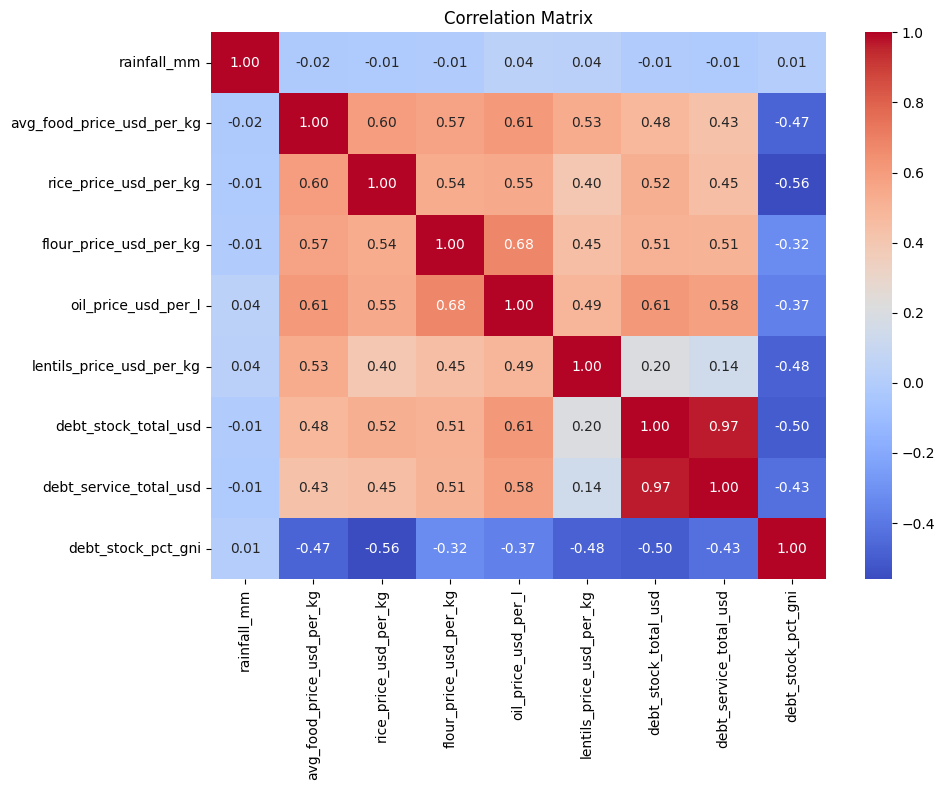

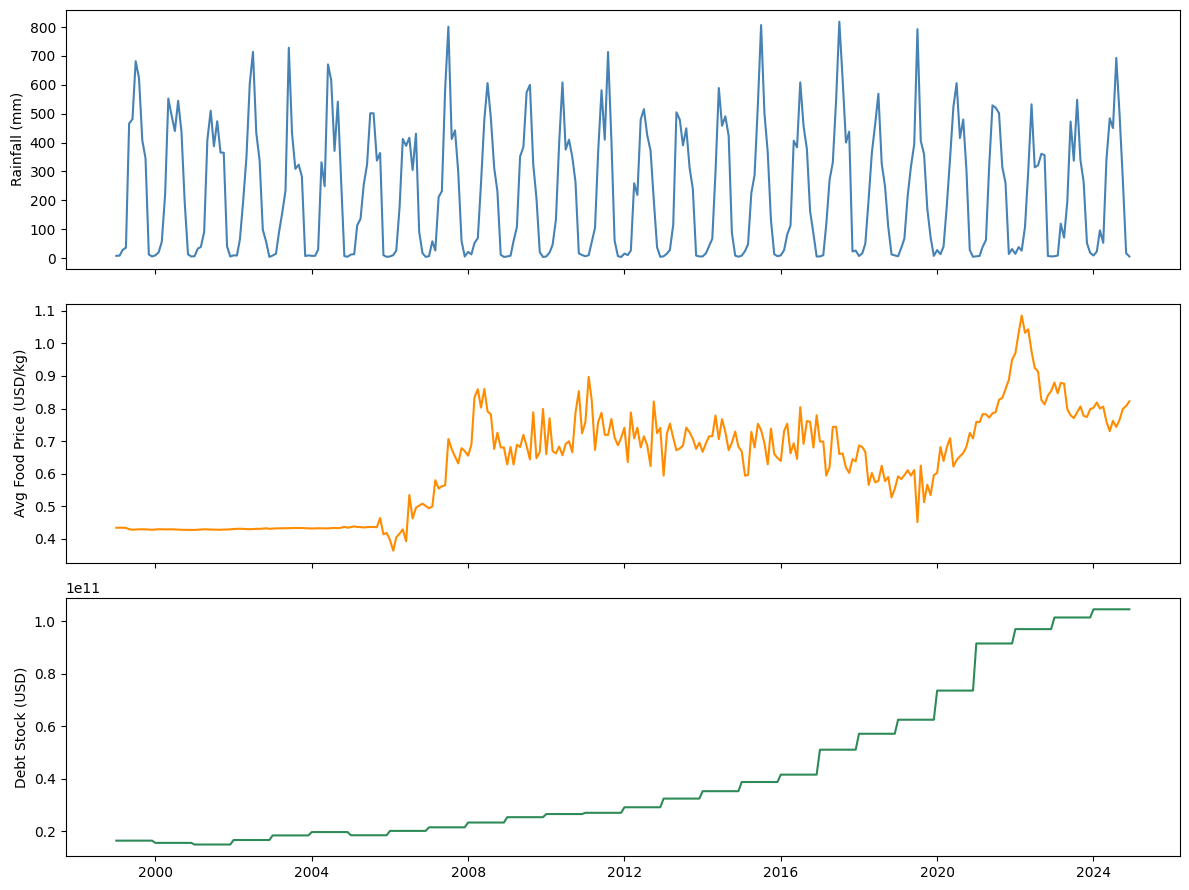

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

m = merged  # Spark DF from Cell 7
cols = ['rainfall_mm','avg_food_price_usd_per_kg','rice_price_usd_per_kg','flour_price_usd_per_kg',
        'oil_price_usd_per_l','lentils_price_usd_per_kg','debt_stock_total_usd','debt_service_total_usd','debt_stock_pct_gni']

corr_pd = m.select(cols).toPandas()  # small, safe
plt.figure(figsize=(10,8))
sns.heatmap(corr_pd.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix'); plt.tight_layout(); plt.show()

nat = m.groupBy('date').agg(F.mean('rainfall_mm').alias('rainfall_mm'),
                             F.mean('avg_food_price_usd_per_kg').alias('avg_food_price_usd_per_kg'),
                             F.mean('debt_stock_total_usd').alias('debt_stock_total_usd')).orderBy('date').toPandas()
fig, ax = plt.subplots(3,1, figsize=(12,9), sharex=True)
ax[0].plot(nat['date'], nat['rainfall_mm'], color='steelblue'); ax[0].set_ylabel('Rainfall (mm)')
ax[1].plot(nat['date'], nat['avg_food_price_usd_per_kg'], color='darkorange'); ax[1].set_ylabel('Avg Food Price (USD/kg)')
ax[2].plot(nat['date'], nat['debt_stock_total_usd'], color='seagreen'); ax[2].set_ylabel('Debt Stock (USD)')
plt.tight_layout(); plt.show()

In [11]:
from pyspark.ml.feature import VectorAssembler, StringIndexer, OneHotEncoder
from pyspark.ml import Pipeline
from pyspark.ml.regression import LinearRegression, DecisionTreeRegressor, RandomForestRegressor
from pyspark.ml.evaluation import RegressionEvaluator

train, test = m.randomSplit([0.8,0.2], seed=1)
idx = StringIndexer(inputCol='pcode', outputCol='pcode_idx')
ohe = OneHotEncoder(inputCol='pcode_idx', outputCol='pcode_ohe')
va = VectorAssembler(inputCols=['rainfall_mm','rainfall_historic_avg_mm','rainfall_anomaly_pct','month','pcode_ohe'], outputCol='features')

price_targets = ['rice_price_usd_per_kg','flour_price_usd_per_kg','oil_price_usd_per_l','lentils_price_usd_per_kg','avg_food_price_usd_per_kg']
for target in price_targets:
    ev = RegressionEvaluator(labelCol=target, predictionCol='prediction', metricName='r2')
    print(f"\n=== rainfall -> {target} ===")
    for Reg, name, kw in [(LinearRegression,'LR',{}),
                           (DecisionTreeRegressor,'DT',{'maxDepth':5,'minInstancesPerNode':20}),
                           (RandomForestRegressor,'RF',{'numTrees':100,'maxDepth':6,'minInstancesPerNode':20})]:
        reg = Reg(featuresCol='features', labelCol=target, **kw)
        pipe = Pipeline(stages=[idx, ohe, va, reg])
        model = pipe.fit(train)
        r2_tr = ev.evaluate(model.transform(train)); r2_te = ev.evaluate(model.transform(test))
        print(f"{name}: TrainR2={r2_tr:.3f} TestR2={r2_te:.3f} Gap={r2_tr-r2_te:.3f}")


=== rainfall -> rice_price_usd_per_kg ===


26/07/04 13:13:26 WARN Instrumentation: [eb45a1ae] regParam is zero, which might cause numerical instability and overfitting.
26/07/04 13:13:27 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
26/07/04 13:13:27 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.lapack.JNILAPACK


LR: TrainR2=0.168 TestR2=0.150 Gap=0.017


DT: TrainR2=0.133 TestR2=0.072 Gap=0.061


26/07/04 13:14:25 WARN DAGScheduler: Broadcasting large task binary with size 1018.4 KiB


...

RF: TrainR2=0.059 TestR2=0.019 Gap=0.040

=== rainfall -> avg_food_price_usd_per_kg ===


26/07/04 13:18:13 WARN Instrumentation: [6b357742] regParam is zero, which might cause numerical instability and overfitting.


LR: TrainR2=0.075 TestR2=0.062 Gap=0.014


DT: TrainR2=0.087 TestR2=0.040 Gap=0.047


RF: TrainR2=0.098 TestR2=0.052 Gap=0.046


In [12]:
va2 = VectorAssembler(inputCols=['rice_price_usd_per_kg','flour_price_usd_per_kg','oil_price_usd_per_l','lentils_price_usd_per_kg','avg_food_price_usd_per_kg'], outputCol='features')
debt_targets = ['debt_stock_total_usd','debt_stock_pct_gni']
for target in debt_targets:
    ev = RegressionEvaluator(labelCol=target, predictionCol='prediction', metricName='r2')
    print(f"\n=== food_prices -> {target} ===")
    for Reg, name, kw in [(LinearRegression,'LR',{}),
                           (DecisionTreeRegressor,'DT',{'maxDepth':5,'minInstancesPerNode':20}),
                           (RandomForestRegressor,'RF',{'numTrees':100,'maxDepth':6,'minInstancesPerNode':20})]:
        reg = Reg(featuresCol='features', labelCol=target, **kw)
        pipe = Pipeline(stages=[va2, reg])
        model = pipe.fit(train)
        r2_tr = ev.evaluate(model.transform(train)); r2_te = ev.evaluate(model.transform(test))
        print(f"{name}: TrainR2={r2_tr:.3f} TestR2={r2_te:.3f} Gap={r2_tr-r2_te:.3f}")


=== food_prices -> debt_stock_total_usd ===


26/07/04 13:25:38 WARN Instrumentation: [6d02546b] regParam is zero, which might cause numerical instability and overfitting.


LR: TrainR2=0.460 TestR2=0.485 Gap=-0.025


DT: TrainR2=0.709 TestR2=0.750 Gap=-0.042


26/07/04 13:26:19 WARN DAGScheduler: Broadcasting large task binary with size 1128.9 KiB


...

26/07/04 13:26:36 WARN Instrumentation: [448f27f3] regParam is zero, which might cause numerical instability and overfitting.


LR: TrainR2=0.418 TestR2=0.347 Gap=0.071


DT: TrainR2=0.643 TestR2=0.599 Gap=0.045


26/07/04 13:27:16 WARN DAGScheduler: Broadcasting large task binary with size 1023.6 KiB


RF: TrainR2=0.654 TestR2=0.609 Gap=0.045


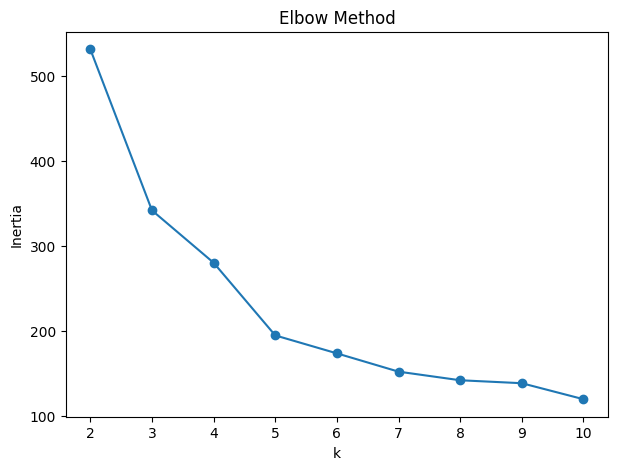

cluster sizes:


+----------+-----+
|prediction|count|
+----------+-----+
|         1|   61|
|         3|   40|
|         2|   34|
|         0|   73|
+----------+-----+

centers: [array([-0.6626096 ,  0.37944549, -0.5890679 , -0.33139096]), array([ 0.86912402,  0.65226156, -0.71851541,  1.28996233]), array([-0.34434734, -1.86741556,  1.24853097, -0.75277453]), array([ 0.17654364, -0.09988368,  1.10953359, -0.7225457 ])]


In [14]:
from pyspark.ml.clustering import KMeans as SparkKMeans
from pyspark.ml.feature import StandardScaler as SparkScaler

agg = m.groupBy('pcode','year').agg(
    F.mean('rainfall_anomaly_pct').alias('rainfall_anomaly_pct'),
    F.mean('avg_food_price_usd_per_kg').alias('avg_food_price_usd_per_kg'),
    F.mean('debt_stock_pct_gni').alias('debt_stock_pct_gni'),
    F.mean('debt_service_total_usd').alias('debt_service_total_usd'))

feat_cols = ['rainfall_anomaly_pct','avg_food_price_usd_per_kg','debt_stock_pct_gni','debt_service_total_usd']
va3 = VectorAssembler(inputCols=feat_cols, outputCol='raw_features')
scaler = SparkScaler(inputCol='raw_features', outputCol='features', withMean=True, withStd=True)
va_scaled = Pipeline(stages=[va3, scaler]).fit(agg).transform(agg)

# elbow
inertias = {}
for k in range(2,11):
    km = SparkKMeans(featuresCol='features', k=k, seed=1)
    inertias[k] = km.fit(va_scaled).summary.trainingCost
plt.figure(figsize=(7,5)); plt.plot(list(inertias.keys()), list(inertias.values()), marker='o')
plt.xlabel('k'); plt.ylabel('Inertia'); plt.title('Elbow Method'); plt.show()

# k=4
km = SparkKMeans(featuresCol='features', k=4, seed=1)
kmodel = km.fit(va_scaled)
result = kmodel.transform(va_scaled)
print("cluster sizes:"); result.groupBy('prediction').count().show()
print("centers:", kmodel.clusterCenters())

In [16]:
from pyspark.ml.feature import VectorAssembler, StringIndexer, OneHotEncoder, StandardScaler as SparkScaler
from pyspark.ml.regression import RandomForestRegressor
from pyspark.ml.clustering import KMeans as SparkKMeans
import numpy as np

# retrain final models on FULL data for demo
idx = StringIndexer(inputCol='pcode', outputCol='pcode_idx')
ohe = OneHotEncoder(inputCol='pcode_idx', outputCol='pcode_ohe')
va = VectorAssembler(inputCols=['rainfall_mm','rainfall_historic_avg_mm','rainfall_anomaly_pct','month','pcode_ohe'], outputCol='features')
price_targets = ['rice_price_usd_per_kg','flour_price_usd_per_kg','oil_price_usd_per_l','lentils_price_usd_per_kg','avg_food_price_usd_per_kg']
price_models = {}
for t in price_targets:
    reg = RandomForestRegressor(featuresCol='features', labelCol=t, numTrees=100, maxDepth=6, minInstancesPerNode=20)
    price_models[t] = Pipeline(stages=[idx, ohe, va, reg]).fit(m)

va2 = VectorAssembler(inputCols=['rice_price_usd_per_kg','flour_price_usd_per_kg','oil_price_usd_per_l','lentils_price_usd_per_kg','avg_food_price_usd_per_kg'], outputCol='features')
debt_reg = RandomForestRegressor(featuresCol='features', labelCol='debt_stock_total_usd', numTrees=100, maxDepth=6, minInstancesPerNode=20)
debt_model = Pipeline(stages=[va2, debt_reg]).fit(m)

# risk clustering (full data), rank clusters by risk
feat_cols = ['rainfall_anomaly_pct','avg_food_price_usd_per_kg','debt_stock_pct_gni','debt_service_total_usd']
va3 = VectorAssembler(inputCols=feat_cols, outputCol='raw_features')
scaler = SparkScaler(inputCol='raw_features', outputCol='features', withMean=True, withStd=True)
km = SparkKMeans(featuresCol='features', k=4, seed=1)
kmodel_full = Pipeline(stages=[va3, scaler, km]).fit(agg)
cs = kmodel_full.stages[-1].clusterCenters()
scores = [(-c[0]+c[1]+c[2]+c[3], i) for i, c in enumerate(cs)]
scores.sort()
risk_labels = {cl: lbl for (score, cl), lbl in zip(scores, ['Low Risk','Moderate Risk','High Risk','Severe Risk'])}

def predict_prices(rainfall_mm, hist_avg_mm, month, pcode):
    anomaly = (rainfall_mm-hist_avg_mm)/hist_avg_mm*100
    row = spark.createDataFrame([(pcode, float(rainfall_mm), float(hist_avg_mm), float(anomaly), int(month))],
                                 ['pcode','rainfall_mm','rainfall_historic_avg_mm','rainfall_anomaly_pct','month'])
    return {t: round(price_models[t].transform(row).select('prediction').first()[0],3) for t in price_targets}

def predict_debt(rice, flour, oil, lentils):
    avg = float(np.mean([rice,flour,oil,lentils]))
    row = spark.createDataFrame([(float(rice), float(flour), float(oil), float(lentils), avg)],
                                 ['rice_price_usd_per_kg','flour_price_usd_per_kg','oil_price_usd_per_l','lentils_price_usd_per_kg','avg_food_price_usd_per_kg'])
    return debt_model.transform(row).select('prediction').first()[0]

def predict_risk(rainfall_anomaly_pct, avg_food_price, debt_pct_gni, debt_service):
    row = spark.createDataFrame([(float(rainfall_anomaly_pct), float(avg_food_price), float(debt_pct_gni), float(debt_service))], feat_cols)
    cl = kmodel_full.transform(row).select('prediction').first()[0]
    return risk_labels[cl]

print("prices:", predict_prices(50, 200, 4, 'BD30'))
print("debt:", predict_debt(0.5,0.5,1.2,1.0))
print("risk:", predict_risk(-30, 0.9, 30, 8e9))

26/07/04 13:59:28 WARN DAGScheduler: Broadcasting large task binary with size 1016.9 KiB
26/07/04 13:59:39 WARN DAGScheduler: Broadcasting large task binary with size 1039.6 KiB
26/07/04 13:59:53 WARN DAGScheduler: Broadcasting large task binary with size 1023.2 KiB
26/07/04 14:00:05 WARN DAGScheduler: Broadcasting large task binary with size 1069.7 KiB
26/07/04 14:00:18 WARN DAGScheduler: Broadcasting large task binary with size 1024.0 KiB
26/07/04 14:00:26 WARN DAGScheduler: Broadcasting large task binary with size 1148.5 KiB


prices: {'rice_price_usd_per_kg': 0.365, 'flour_price_usd_per_kg': 0.39, 'oil_price_usd_per_l': 0.974, 'lentils_price_usd_per_kg': 0.932, 'avg_food_price_usd_per_kg': 0.562}
debt: 89366743222.49931
risk: Severe Risk
